In [67]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Learn Gaussian parameters with CNNs

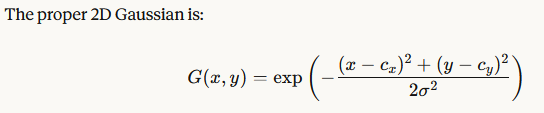

In [ ]:
# create a guassian blur with different widths
n_images = 1000 # number of samples in total
img_size = 91


x = np.linspace(-4, 4, img_size)
X, Y = np.meshgrid(x, x)

images = torch.zeros((n_images, 1, img_size, img_size)) # create a tensor to hold the images
labels = torch.zeros(n_images, 3) # create a tensor to hold the labels

for i in range(n_images):
        # location and width of the gaussian blur
        center = 2*np.random.randn(2) # randomly shift the center of the gaussian blur
        width = np.random.rand() * 10 + 5 # randomly choose a width between 5 and 15
        
        # we divided by the width to make it simpler, therefore we are predicitng width = 2*sigma^2
        # later we can extract sigma from the predicted width using sigma = sqrt(width/2)
        gauss = np.exp(-((X - center[0])**2 + (Y - center[1])**2) / width) # create a gaussian blur with the given width and center
        gauss = gauss + np.random.randn(img_size, img_size) * 0.1 # add some noise to the image

        images[i] = torch.tensor(gauss).view(1, img_size, img_size) # store the image in the tensor
        labels[i] = torch.tensor([center[0], center[1], width]) # store the labels in the tensor

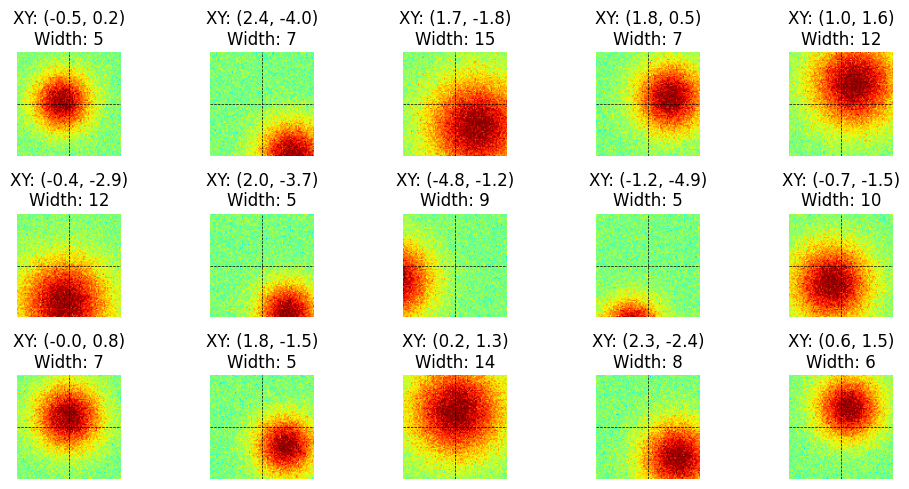

In [69]:
# visualize
fig, ax = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    random_pic = np.random.randint(n_images) # randomly select an image from the dataset
    ax.imshow(images[random_pic].squeeze(), cmap='jet', vmin=-1, vmax=1, extent=(-4, 4, -4, 4), origin="lower") # visualize the image
    ax.set_title(f"XY: ({labels[random_pic][0]:.1f}, {labels[random_pic][1]:.1f})\nWidth: {labels[random_pic][2]:.0f}")
    ax.plot([-4, 4], [0, 0], 'k--', lw=0.5) # add x-axis
    ax.plot([0, 0], [-4, 4], 'k--', lw=0.5) # add y-axis
    ax.axis('off')

plt.tight_layout()
plt.show()

In [70]:
# create train and test dataloaders for occluded -> clean reconstruction
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [71]:
class GausNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1), # output: (6, 91, 91)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: (6, 45, 45)

            nn.Conv2d(in_channels=6, out_channels=4, kernel_size=3, stride=1, padding=1), # output: (4, 45, 45)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: (4, 22, 22)
        )

        self.fnn = nn.Sequential(
            nn.Flatten(), # output: (4*22*22,)
            nn.Linear(4*22*22, 50), # output: (50,)
            nn.ReLU(),
            nn.Linear(50, 3) # output: (3,) -> (x_center, y_center, width)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.fnn(x)
        return x
    
model = GausNet()
summary(model, input_size=(1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
           Flatten-7                 [-1, 1936]               0
            Linear-8                   [-1, 50]          96,850
              ReLU-9                   [-1, 50]               0
           Linear-10                    [-1, 3]             153
Total params: 97,283
Trainable params: 97,283
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.00
Params size (MB): 0.37
Estimated Tot

In [72]:
# test the model with a batch of data
# we have to ensure that the input and output shapes are correct before we start training the model, otherwise we might run into errors during training
model = GausNet()
images_occ, images_clean = next(iter(train_dataloader))
outputs = model(images_occ)
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, images_clean)
print(f"Occluded images shape: {images_occ.shape}")
print(f"Input shape: {images_clean.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Loss: {loss.item()}")

Occluded images shape: torch.Size([16, 1, 91, 91])
Input shape: torch.Size([16, 3])
Output shape: torch.Size([16, 3])
Loss: 36.94157028198242


In [73]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    ):
    model.train()
    train_loss = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, y)
        train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int = 5,
          ):

    train_losses_epochs = []
    test_losses_epochs = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        train_losses_epochs.append(avg_train_loss)

        # Evaluate on the test set
        model.eval()
        test_loss = 0.0

        with torch.no_grad():
            for X, y in test_dataloader:
                outputs = model(X)
                loss = loss_fn(outputs, y)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_dataloader)
        test_losses_epochs.append(avg_test_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Test Loss: {avg_test_loss:.4f}"
        )

    return train_losses_epochs, test_losses_epochs

In [74]:
epochs = 30
model = GausNet()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loss, test_loss = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch [1/30], Train Loss: 11.7255, Test Loss: 3.7458
Epoch [2/30], Train Loss: 2.9149, Test Loss: 2.0659
Epoch [3/30], Train Loss: 1.9949, Test Loss: 1.9092
Epoch [4/30], Train Loss: 1.7623, Test Loss: 1.7604
Epoch [5/30], Train Loss: 1.5268, Test Loss: 1.3106
Epoch [6/30], Train Loss: 1.1411, Test Loss: 0.9830
Epoch [7/30], Train Loss: 0.8556, Test Loss: 0.9067
Epoch [8/30], Train Loss: 0.8091, Test Loss: 0.7258
Epoch [9/30], Train Loss: 0.7133, Test Loss: 0.6764
Epoch [10/30], Train Loss: 0.6750, Test Loss: 0.6418
Epoch [11/30], Train Loss: 0.6451, Test Loss: 0.6313
Epoch [12/30], Train Loss: 0.5960, Test Loss: 0.5837
Epoch [13/30], Train Loss: 0.5848, Test Loss: 0.5737
Epoch [14/30], Train Loss: 0.5488, Test Loss: 0.5169
Epoch [15/30], Train Loss: 0.5151, Test Loss: 0.4847
Epoch [16/30], Train Loss: 0.4741, Test Loss: 0.4177
Epoch [17/30], Train Loss: 0.4231, Test Loss: 0.4359
Epoch [18/30], Train Loss: 0.3847, Test Loss: 0.3936
Epoch [19/30], Train Loss: 0.3612, Test Loss: 0.4280
E

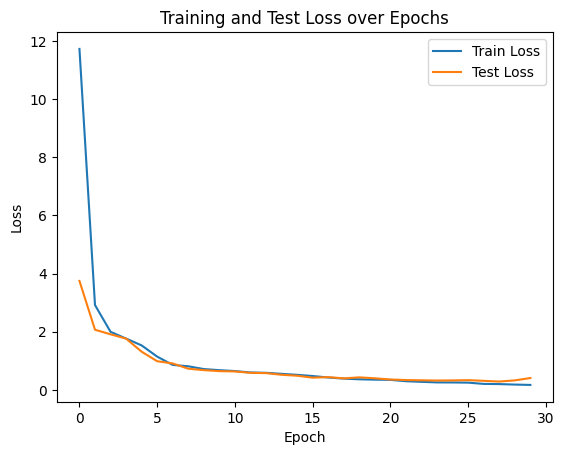

In [75]:
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.show()

In [76]:
# Visualize some predictions with 2 decimal places for the labels
model.eval()
with torch.no_grad():
    for i in range(5):
        X, y = test_dataset[i]
        output = model(X.unsqueeze(0)) # add batch dimension
        print(f"True labels: {y[0]:.2f}, {y[1]:.2f}, {y[2]:.2f}, Predicted labels: {output[0,0]:.2f}, {output[0,1]:.2f}, {output[0,2]:.2f}")

True labels: -0.69, -0.03, 6.27, Predicted labels: -0.48, 0.03, 6.68
True labels: -2.69, -3.83, 7.89, Predicted labels: -3.09, -4.38, 9.85
True labels: -0.83, 0.57, 12.69, Predicted labels: -0.53, 0.54, 13.06
True labels: 2.07, 1.30, 8.53, Predicted labels: 2.26, 1.40, 9.25
True labels: -2.13, 0.21, 12.64, Predicted labels: -1.88, 0.18, 13.74


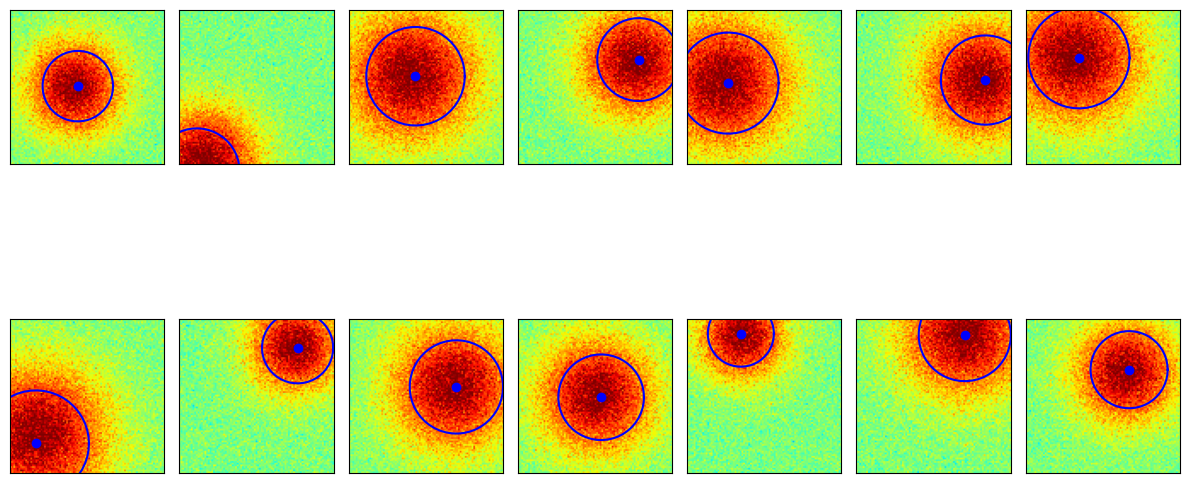

In [ ]:
# plot the image and then plot a circle with the predicted center and width
th = np.linspace(0, 2*np.pi) # theta for plotting the circle

fig, axs = plt.subplots(2, 7, figsize=(12, 8))

model.eval()
with torch.no_grad():
    for i, ax in enumerate(axs.flatten()):
        X, y = test_dataset[i]
        output = model(X.unsqueeze(0)) # add batch dimension
        x_center = output[0, 0].item()
        y_center = output[0, 1].item()
        radius = output[0, 2].item() # as explained above, we can extract sigma from the predicted width using sigma = sqrt(width/2)
        
        ax.imshow(X.squeeze(), cmap='jet', vmin=-1, vmax=1, extent=(-4, 4, -4, 4), origin="lower")
        x = x_center + np.cos(th) * np.sqrt(radius / 2)
        y = y_center + np.sin(th) * np.sqrt(radius / 2)
        ax.plot(x, y, 'b')
        ax.plot(x_center, y_center, 'bo') # plot the predicted center

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)

plt.tight_layout()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


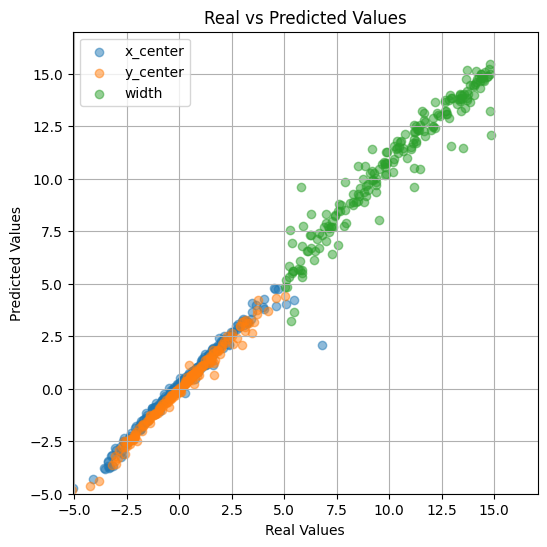

In [103]:
# put all the real values in one array, all the predicted in another, and plot and scatter plot
real_values = []
predicted_values = []
model.eval()
with torch.no_grad():
    for i in range(len(test_dataset)):
        X, y = test_dataset[i]
        output = model(X.unsqueeze(0)) # add batch dimension
        real_values.append(y.numpy())
        predicted_values.append(output.numpy().squeeze())
real_values = np.array(real_values)
predicted_values = np.array(predicted_values)
plt.figure(figsize=(6, 6))
plt.scatter(real_values[:, 0], predicted_values[:, 0], label='x_center', alpha=0.5)
plt.scatter(real_values[:, 1], predicted_values[:, 1], label='y_center', alpha=0.5)
plt.scatter(real_values[:, 2], predicted_values[:, 2], label='width', alpha=0.5)
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')
plt.title('Real vs Predicted Values')
plt.axis('equal')
plt.grid()
plt.xlim(-5, 17)
plt.ylim(-5, 17)
plt.legend()
plt.show()
